# Corso di Big Data — Modulo Machine Learning per i Big Data
## Prova scritta del 4 giugno 2026

Si consideri il dataset `housing.csv`, allegato al presente compito, costituito da 20640 record che descrivono il valore medio di uno stabile in California sulla base delle seguenti caratteristiche:

* **longitude**
* **latitude**
* **housing_median_age**
* **total_rooms** (numero totale di camere nello stabile)
* **total_bedrooms** (numero totale di camere da letto nello stabile)
* **population** (numero di abitanti dello stabile)
* **households** (numero di famiglie nello stabile)
* **median_income**
* **median_house_value**
* **ocean_proximity**

---

### Esercizio 1 (Punti: __ / 8)
Eseguire uno split train/validation/test **80% / 5% / 15%**. 
Individuare eventuali dati mancanti, farne l'imputazione e procedere all'encoding più opportuno per le feature categoriche oltre all'eventuale scalatura di tutte le feature. 

Verificare la presenza di feature multicollineari e sostituirle con opportune combinazioni lineari. Infine eseguire la feature selection per individuare le caratteristiche più rilevanti del dataset attraverso una tecnica **embedded** che impieghi un regressore **Lasso** come modello. Infatti, sappiamo che la regressione lineare attribuisce coefficienti piccoli o nulli alle feature che influenzano poco la predizione.

---

### Esercizio 2 (Punti: __ / 6)
Implementare una regressione **Ridge** ed una con **Random Forest** per il dataset processato al punto 1. 
Confrontarne le prestazioni in termini di $Mio\_MSE$ (o MSE) e di $R^2$ sia sul training set sia sul test set.

---

### Esercizio 3 (Punti: __ / 10)
Implementare una piccola **rete neurale densa** con almeno due layer nascosti in **PyTorch**, utilizzando la semplice API `torchnn.py`, per eseguire la classificazione binaria. 

Si dovrà implementare anche il relativo `Dataset` per caricare i dati. La rete andrà addestrata per un massimo di 30 epoche. I soli layer nascosti dovranno avere un **dropout pari a 0.2**. Si utilizzi per l'addestramento l'ottimizzatore **Adam** con weight decay pari a $1 \times 10^{-4}$ e learning rate decrescente linearmente a partire da 0.01. Utilizzare l'**early stopping** con una pazienza sulla validation loss di 10 epoche e un incremento minimo di miglioramento pari a 0.001. Salvare il miglior modello rispetto al minimo MSE.

---

### Esercizio 4 (Punti: __ / 6)
Confrontare i risultati del regressore neurale sul test set con i modelli precedenti stampando i valori di MSE e $R^2$. 

Confrontare le performance dei tre regressori, stampando, per ciascuno di essi, il **boxplot** dei tre andamenti del MSE e di $R^2$ sui singoli campioni del test set.

---
**TOTALE: punti __ / 30**

### Esercizio 1 (Punti: __ / 8)
Eseguire uno split train/validation/test **80% / 5% / 15%**. 
Individuare eventuali dati mancanti, farne l'imputazione e procedere all'encoding più opportuno per le feature categoriche oltre all'eventuale scalatura di tutte le feature. 

Verificare la presenza di feature multicollineari e sostituirle con opportune combinazioni lineari. Infine eseguire la feature selection per individuare le caratteristiche più rilevanti del dataset attraverso una tecnica **embedded** che impieghi un regressore **Lasso** come modello. Infatti, sappiamo che la regressione lineare attribuisce coefficienti piccoli o nulli alle feature che influenzano poco la predizione

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd 

df = pd.read_csv('housing.csv')

print(df.shape)
df = df.dropna(subset=['median_house_value'])
print(df.shape)

X = df.drop( columns=['median_house_value'])
y = df.median_house_value

X_tr, X_te, y_tr, y_te = train_test_split(X,y, test_size=0.15)

val_size = (5/100) / (85/100)

X_tr, X_val , y_tr, y_val = train_test_split(X_tr,y_tr, test_size= val_size)

print(val_size)

(20640, 10)
(20640, 10)
0.05882352941176471


In [2]:
#print( X_tr.isna().sum())
#print( X_te.isna().sum())
#print(X_val.isna().sum())

#ho bissogno di fare imputazione

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

imputer1 = SimpleImputer(strategy='median').set_output(transform='pandas')
imputer2 = SimpleImputer(strategy='constant').set_output(transform='pandas')

num_f = X_tr.select_dtypes( include=['number']).columns.tolist()
cat_f = [col for col in X_tr.columns if col not in num_f]


X_tr_num = imputer1.fit_transform( X_tr[num_f] )
X_te_num = imputer1.transform( X_te[num_f] )
X_val_num = imputer1.transform( X_val[num_f] )

X_tr_cat = imputer2.fit_transform( X_tr[cat_f] )
X_te_cat = imputer2.transform( X_te[cat_f] )
X_val_cat = imputer2.transform( X_val[cat_f] )

encoder = OrdinalEncoder().set_output(transform='pandas')

X_tr_cat = encoder.fit_transform( X_tr_cat )
X_te_cat = encoder.transform(  X_te_cat )
X_val_cat = encoder.transform( X_val_cat )

#rimetto i dataframe insieme

X_tr = pd.concat( [X_tr_num, X_tr_cat], axis=1)
X_te = pd.concat( [X_te_num, X_te_cat], axis=1)
X_val = pd.concat( [X_val_num, X_val_cat], axis=1)

print( X_tr.isna().sum())
print( X_te.isna().sum())
print(X_val.isna().sum())



longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform='pandas')

X_tr = scaler.fit_transform( X_tr )
X_te = scaler.fit_transform( X_te )
X_val = scaler.fit_transform( X_val )

In [4]:

corr_matrix = X_tr.corr().abs()

threshold = 0.7

#print(corr_matrix)

groups = [('longitude','latitude'),('population','total_bedrooms','total_rooms', 'households')]


for group in groups:
    print(group)
    for df in [X_tr,X_val,X_te]:
        df['_'.join(group)] = df[list(group)].mean(axis=1)
        df.drop(columns=list(group), inplace=True)

print(X_tr)



('longitude', 'latitude')


('population', 'total_bedrooms', 'total_rooms', 'households')
       housing_median_age  median_income  ocean_proximity  longitude_latitude  \
1393            -0.289719       1.292312         1.291826           -0.086374   
19756           -0.766238      -0.994574        -0.115672            0.394144   
15542           -1.004497       2.493899        -0.819421            0.015677   
13020           -0.448559       0.303956        -0.115672            0.309076   
4665             0.186799      -0.840787        -0.819421           -0.054190   
...                   ...            ...              ...                 ...   
8353             1.219255       0.406515        -0.819421           -0.082619   
669              0.583897      -0.221947         1.291826           -0.159792   
14721           -0.210300       1.031441        -0.819421           -0.032473   
14408            0.742737       0.534350         1.995574           -0.094422   
14092           -0.607398      -0.844948       

In [5]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

model = Lasso(alpha=1.0)

sel = SelectFromModel(estimator=model,threshold='median')
print(X_tr.shape)

X_tr = sel.fit_transform( X_tr , y_tr)
X_te = sel.transform( X_te )
X_val = sel.transform( X_val )

print(X_tr.shape)

(16512, 5)
(16512, 3)


### Esercizio 2 (Punti: __ / 6)
Implementare una regressione **Ridge** ed una con **Random Forest** per il dataset processato al punto 1. 
Confrontarne le prestazioni in termini di $Mio\_MSE$ (o MSE) e di $R^2$ sia sul training set sia sul test set.

---

In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

regressor1 = Ridge(alpha=1.0)
regressor2 = RandomForestRegressor(n_estimators=50, criterion='squared_error', min_samples_split=100)

#1

model1 = regressor1.fit(X_tr, y_tr)

y_pred_1 = regressor1.predict( X_te)

score_r2_1 = r2_score( y_te, y_pred_1 )
mse_1 = mean_squared_error( y_te, y_pred_1 )

#2 

model2 = regressor2.fit(X_tr, y_tr)

y_pred_2 = regressor2.predict( X_te)

score_r2_2 = r2_score( y_te, y_pred_2 )
mse_2 = mean_squared_error( y_te, y_pred_2)

print(f'r2_1: {score_r2_1}')
print(f'r2_2: {score_r2_2}')
print(f'mse_1: {score_r2_1}')
print(f'mse_2: {score_r2_2}')

'''
r2_1: 0.5914939378073532
r2_2: 0.679487260452086
mse_1: 0.5914939378073532
mse_2: 0.679487260452086

il secondo modello ha statistiche migliori
'''

r2_1: 0.564323117358653
r2_2: 0.650593329862255
mse_1: 0.564323117358653
mse_2: 0.650593329862255


'\nr2_1: 0.5914939378073532\nr2_2: 0.679487260452086\nmse_1: 0.5914939378073532\nmse_2: 0.679487260452086\n\nil secondo modello ha statistiche migliori\n'


### Esercizio 4 (Punti: __ / 6)
Confrontare i risultati del regressore neurale sul test set con i modelli precedenti stampando i valori di MSE e $R^2$. 

Confrontare le performance dei tre regressori, stampando, per ciascuno di essi, il **boxplot** dei tre andamenti del MSE e di $R^2$ sui singoli campioni del test set.

/tmp/ipykernel_108260/457660975.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


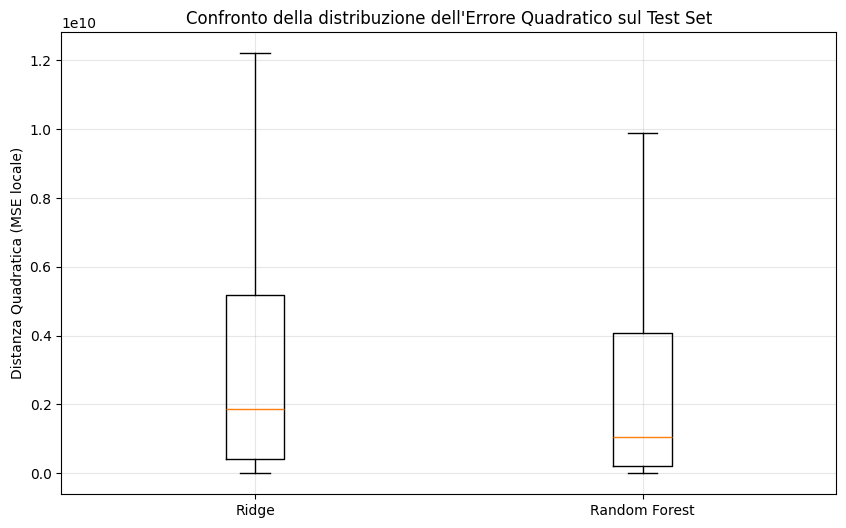

/tmp/ipykernel_108260/457660975.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


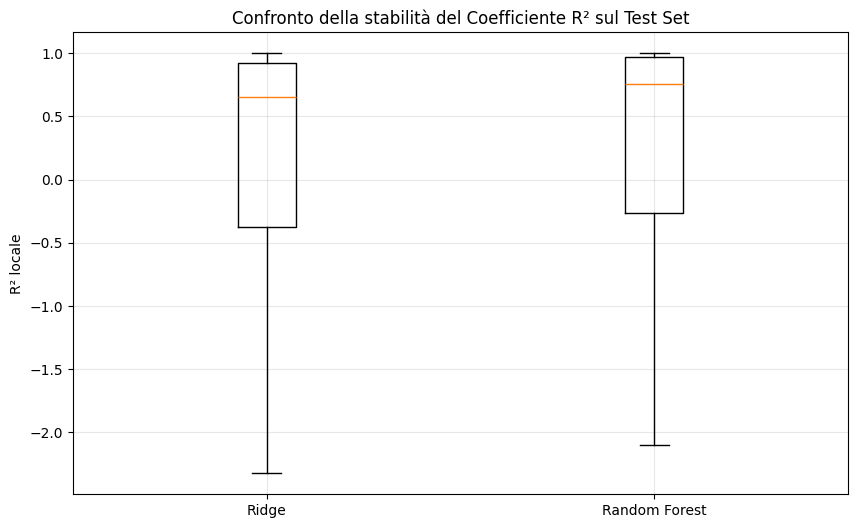

In [10]:
import matplotlib.pyplot as plt
import numpy as np


# Assumiamo che tu abbia già i vettori delle predizioni sul Test Set:
# y_pred_ridge, y_pred_rf, y_pred_nn (e il target reale y_test)
# Convertiamo tutto in array numpy per sicurezza computazionale
y_true = np.array(y_te)

# --- 1. CALCOLO DEI VETTORI DI ERRORE QUADRATICO PUNTUALE (MSE) ---
mse_punti_ridge = (y_true - y_pred_1) ** 2
mse_punti_rf = (y_true - y_pred_2) ** 2


# --- 2. CALCOLO DEI VETTORI DI R2 PUNTUALE ---
varianza_totale = (y_true - np.mean(y_true)) ** 2
# Evitiamo divisioni per zero se un campione coincide perfettamente con la media
varianza_totale = np.where(varianza_totale == 0, 1e-9, varianza_totale)

r2_punti_ridge = 1 - (mse_punti_ridge / varianza_totale)
r2_punti_rf = 1 - (mse_punti_rf / varianza_totale)


# ==========================================
# FASE PLOT: 2 Figure distinte come richiesto
# ==========================================

# GRAFICO 1: Confronto Boxplot MSE
plt.figure(figsize=(10, 6))
dati_mse = [mse_punti_ridge, mse_punti_rf]
plt.boxplot(
    dati_mse,
    labels=["Ridge", "Random Forest"],
    showfliers=False,
)  # showfliers=False nasconde gli outlier estremi per rendere il grafico leggibile
plt.ylabel("Distanza Quadratica (MSE locale)")
plt.title("Confronto della distribuzione dell'Errore Quadratico sul Test Set")
plt.grid(True, alpha=0.3)
plt.show()

# GRAFICO 2: Confronto Boxplot R²
plt.figure(figsize=(10, 6))
dati_r2 = [r2_punti_ridge, r2_punti_rf]
plt.boxplot(
    dati_r2,
    labels=["Ridge", "Random Forest"],
    showfliers=False,
)
plt.ylabel("R² locale")
plt.title("Confronto della stabilità del Coefficiente R² sul Test Set")
plt.grid(True, alpha=0.3)
plt.show()